In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


1. Setup & Imports

Standard scientific-Python stack: numpy (math), pandas (tables), matplotlib (plots).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

2. Load the Data & Explore (EDA)

Before modeling, understand the data: shape → head → info (dtypes) → isna().sum() (missing values) → describe (ranges) → target balance → correlations with the target.

Why this matters: EDA dictates the whole strategy. Here the data is all numeric with no missing values (rare and lucky), the target is roughly balanced (~165 vs ~138, so accuracy is a fair metric), and features like cp (chest pain) and thalach (max heart rate) correlate most with disease.

In [3]:
df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

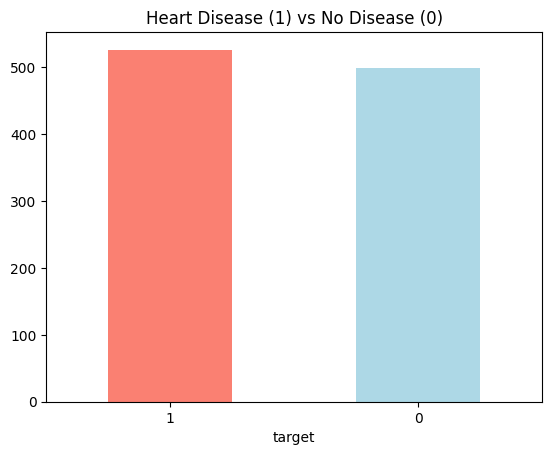

In [9]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"])
plt.title("Heart Disease (1) vs No Disease (0)")
plt.xticks(rotation=0);

In [10]:
df.corr()["target"].sort_values(ascending=False)

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

3. Features (X), Target (y) & Train/Test Split

Split the table into X (the 13 input columns) and y (the target answer), then hold out 20% as a test set the models never see during training.

random_state=42 → reproducible split (same rows every run).
stratify=y → keeps the disease/no-disease ratio identical in train and test (good practice for classification).
Golden rule: the test set is sacred — touch it only for the final score, never for training or tuning.

In [11]:
X = df.drop("target", axis=1)   # everything EXCEPT the answer
y = df["target"]                # just the answer
X.shape, y.shape

((1025, 13), (1025,))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((820, 13), (205, 13))

4. Baseline Model Comparison

Try many model families with default settings (no scaling, no tuning) to get a starting point. Putting models in a dictionary lets us loop and treat them identically.

What to expect: tree-based models (RandomForest, GradientBoosting, XGBoost, CatBoost) do well out-of-the-box because they're scale-invariant. KNN and SVM look weak here — not because they're bad, but because we fed them unscaled data (they rely on distances). That's the lesson that motivates Section 5.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [14]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":            XGBClassifier(random_state=42),
    "CatBoost":           CatBoostClassifier(random_state=42, verbose=0),
    "NaiveBayes":         GaussianNB(),
}

In [15]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)                    # train on training data
    results[name] = model.score(X_test, y_test)    # accuracy on unseen test data
results

{'LogisticRegression': 0.8146341463414634,
 'KNN': 0.697560975609756,
 'SVM': 0.7170731707317073,
 'DecisionTree': 0.9853658536585366,
 'RandomForest': 1.0,
 'GradientBoosting': 0.975609756097561,
 'XGBoost': 1.0,
 'CatBoost': np.float64(1.0),
 'NaiveBayes': 0.8292682926829268}

In [16]:
results_df = pd.DataFrame(results, index=["accuracy"]).T
results_df.sort_values("accuracy", ascending=False)

,accuracy
RandomForest,1.000000
CatBoost,1.000000
XGBoost,1.000000
DecisionTree,0.985366
GradientBoosting,0.975610
NaiveBayes,0.829268
LogisticRegression,0.814634
SVM,0.717073
KNN,0.697561


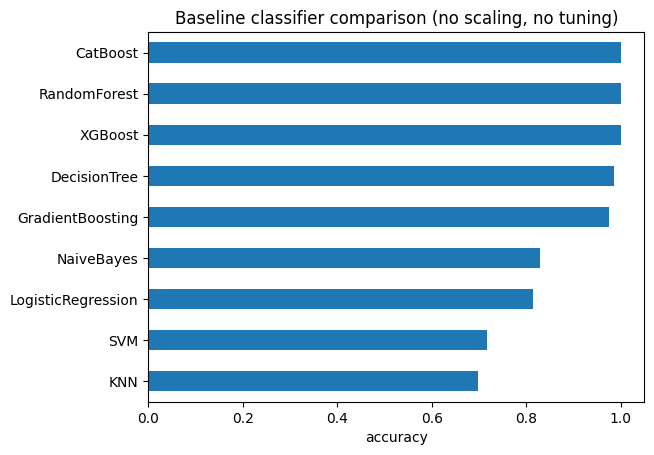

In [17]:
results_df.sort_values("accuracy").plot(kind="barh", legend=False)
plt.xlabel("accuracy")
plt.title("Baseline classifier comparison (no scaling, no tuning)");